<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulacion-I/blob/main/Mccrudo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método de Monte Carlo Crudo

Queremos estimar el valor de la interal:

$$I=\int_{a}^{b}g(x)dx$$

Partimos de la fórmula para calcular el valor esperado de una función de la variable aleatoria $X$.

Sea $X~f(x)=U(a,b)=\frac{1}{b-a}$, así:

$$E(g(x))=\int^b_ag(x)\frac{1}{b-a}dx=\frac{1}{b-a}\int^b_ag(x)dx=\frac{I}{b-a}$$

$$\Rightarrow I=(b-a)E(g(x))$$

Y podemos usar el promedio como un estimador de $E(g(x))$.

$$E(g(x))\approx\frac{1}{N}\sum^N_{i=0} g(x_i), i=0,1,2,...,N$$

Por lo tanto:

$$\hat{I}≈\frac{b-a}{N}∑^N_{i=1}g(x_i), i=0,1,...,N$$

Si $X_i~U(a,b)$.



Ejemplo:

Estimar el valor de la integral

$$I=\int^1_0\sqrt{arctan(x)}dx$$

In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

Defino la función $\sqrt{arctan(x)}$:

In [2]:
def f(x):
    return np.sqrt(np.arctan(x))

In [3]:
f(1)

np.float64(0.8862269254527579)

La gráfica de la función:

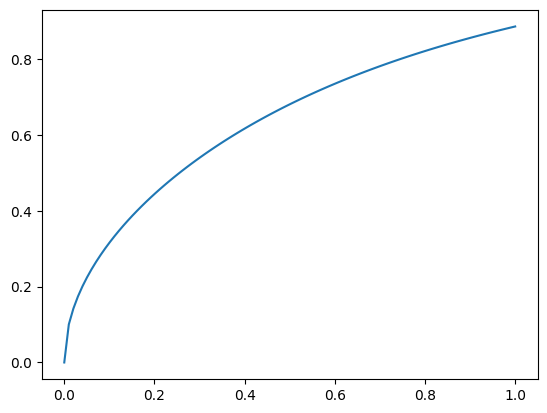

In [4]:
xx=np.linspace(0,1,100)
plt.plot(xx, f(xx))

Defino la función del método de Monte Carlo crudo:

In [5]:
def mcc(a, b, N):
    I=0
    for i in range(N):
        x=r.random()
        I+=f(x)
    return I/N

Llamo a la función, usando $a=0$, $b=1$ y $N=1000$:

In [6]:
mcc(0,1,1000)

np.float64(0.6409605232055413)

Defino la función que hará el vector de experimentos con $M$ entradas:

In [7]:
def experimento(M):
    L=[]
    for i in range(M):
        I=mcc(0,1,i+1)
        L.append(I)
    return L

Para el ejemplo, en la clase vimos que al poner distintos valores de $M$, el valor que requiere menos recursos computacionales, es $M=600$ el experimento converge:

In [8]:
E=experimento(600)

Ahora será graficado el vector de experimentos:

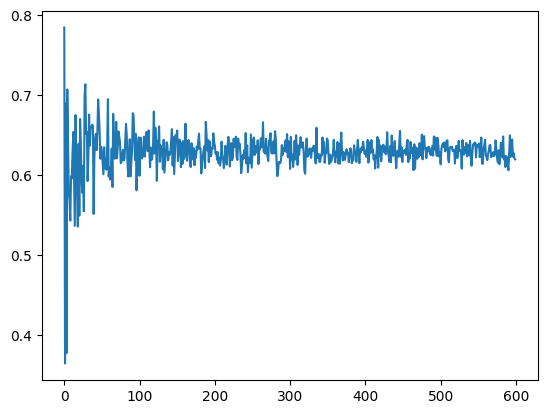

In [9]:
plt.plot(E)

Se calcula la media del vector de experimentos:


In [10]:
np.mean(E)

np.float64(0.6295147793484169)

Defino la función que hará las $F$ simulaciones:

In [21]:
def simulaci(F):
    Li=[]
    for i in range(F):
        e=np.mean(experimento(600))
        Li.append(e)
    return Li

Llamo a la función y haremos $100$ simulaciones:

In [22]:
p=simulaci(100)

Ahora un histograma de las simulaciones:

(array([ 3.,  3.,  8.,  9., 20., 21., 15.,  9.,  8.,  4.]),
 array([0.62741664, 0.62784642, 0.62827619, 0.62870596, 0.62913573,
        0.62956551, 0.62999528, 0.63042505, 0.63085482, 0.6312846 ,
        0.63171437]),
 <BarContainer object of 10 artists>)

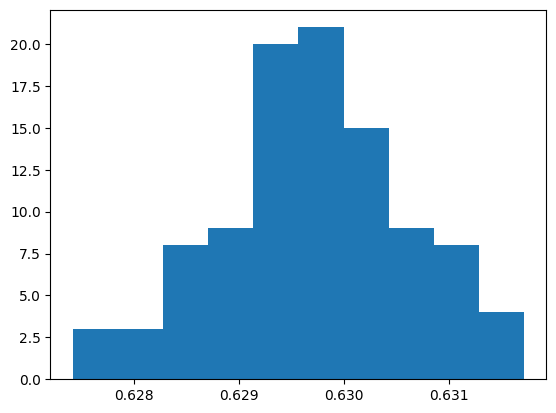

In [23]:
plt.hist(p)